In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, classification_report)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
 # For Task 6 app (optional in notebook)

# Load data
df = pd.read_csv('elo_features.csv')
print(f"Dataset shape: {df.shape}")
print("\nTarget distribution:\n", df['result_numeric'].value_counts(normalize=True))

# Map target: 0=draw, 1=home win, 2=away win
df['target'] = df['result_numeric'].map({0: 0, 1: 1, -1: 2})

# Features (all used: manual select based on domain—ELO diffs key for soccer)
features = ['elo_diff_before', 'expected_home_win', 'goal_margin_factor', 'rank_diff']
X = df[features]
y = df['target']

# 80/10/10 Split (stratified shuffle for balance)
# First: 80% train + 20% temp (for val+test)
X_train_temp, X_test, y_train_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
# Then: From temp, 50/50 for val/test (overall: 80% train, 10% val, 10% test)
X_train, X_val, y_train, y_val = train_test_split(X_train_temp, y_train_temp, test_size=0.5, random_state=42, stratify=y_train_temp)

print(f"Train: {X_train.shape} ({len(X_train)/len(X)*100:.1f}%) | Val: {X_val.shape} ({len(X_val)/len(X)*100:.1f}%) | Test: {X_test.shape} ({len(X_test)/len(X)*100:.1f}%)")

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# CV on train only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression: Tune on train
lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=42, max_iter=1000)
lr_params = {'C': [0.1, 1, 10]}
lr_grid = GridSearchCV(lr, lr_params, cv=cv, scoring='accuracy')
lr_grid.fit(X_train_scaled, y_train)
best_lr = lr_grid.best_estimator_
print("\nBest LR Params (on train):", lr_grid.best_params_)
print("LR Train CV Acc:", lr_grid.best_score_)

# Random Forest: Tune on train
rf = RandomForestClassifier(random_state=42)
rf_params = {'n_estimators': [50, 100], 'max_depth': [3, 5, None], 'min_samples_split': [2, 5]}
rf_grid = GridSearchCV(rf, rf_params, cv=cv, scoring='accuracy')
rf_grid.fit(X_train, y_train)  # RF no scale
best_rf = rf_grid.best_estimator_
print("\nBest RF Params (on train):", rf_grid.best_params_)
print("RF Train CV Acc:", rf_grid.best_score_)

Dataset shape: (241, 21)

Target distribution:
 result_numeric
 1    0.456432
-1    0.323651
 0    0.219917
Name: proportion, dtype: float64
Train: (108, 4) (44.8%) | Val: (108, 4) (44.8%) | Test: (25, 4) (10.4%)


C:\Users\cbsen\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\cbsen\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\cbsen\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\cbsen\AppData\Local\Programs\Python\P


Best LR Params (on train): {'C': 0.1}
LR Train CV Acc: 0.7329004329004329

Best RF Params (on train): {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
RF Train CV Acc: 0.6948051948051949



LR Val Metrics:
               precision    recall  f1-score   support

        Draw       1.00      1.00      1.00        24
    Home Win       0.72      0.84      0.77        49
    Away Win       0.70      0.54      0.61        35

    accuracy                           0.78       108
   macro avg       0.81      0.79      0.80       108
weighted avg       0.78      0.78      0.77       108


RF Val Metrics:
               precision    recall  f1-score   support

        Draw       1.00      1.00      1.00        24
    Home Win       0.73      0.76      0.74        49
    Away Win       0.64      0.60      0.62        35

    accuracy                           0.76       108
   macro avg       0.79      0.79      0.79       108
weighted avg       0.76      0.76      0.76       108


Best Model on Val (F1): LR (0.772)

LR Test Metrics:
               precision    recall  f1-score   support

        Draw       1.00      1.00      1.00         6
    Home Win       0.67      0.91     

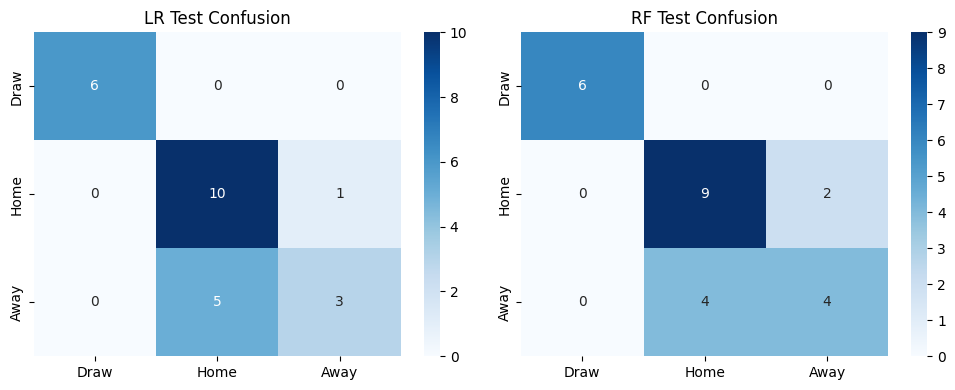

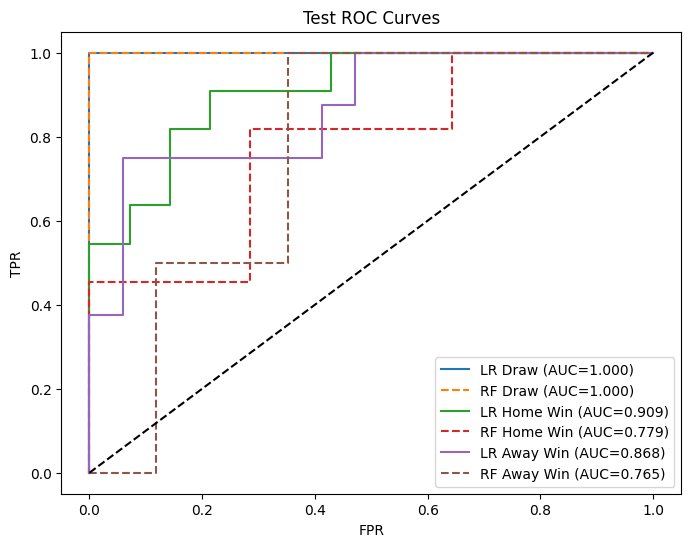

In [24]:
# Predictions on val (for model selection) and test
y_pred_lr_val = best_lr.predict(X_val_scaled)
y_pred_rf_val = best_rf.predict(X_val)
y_pred_lr_test = best_lr.predict(X_test_scaled)
y_pred_rf_test = best_rf.predict(X_test)

# Metrics function
def compute_metrics(y_true, y_pred, proba_func, X_data, model_name, set_name=''):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    y_true_bin = label_binarize(y_true, classes=[0,1,2])
    y_pred_proba = proba_func(X_data)  # LR or RF proba
    auc = roc_auc_score(y_true_bin, y_pred_proba, multi_class='ovr')
    print(f"\n{model_name} {set_name} Metrics:\n", classification_report(y_true, y_pred, target_names=['Draw', 'Home Win', 'Away Win']))
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC-AUC': auc}

# Val metrics (for selection: Pick RF if val F1 > LR)
metrics_lr_val = compute_metrics(y_val, y_pred_lr_val, lambda x: best_lr.predict_proba(x), X_val_scaled, 'LR', 'Val')
metrics_rf_val = compute_metrics(y_val, y_pred_rf_val, lambda x: best_rf.predict_proba(x), X_val, 'RF', 'Val')
best_model = 'RF' if metrics_rf_val['F1'] > metrics_lr_val['F1'] else 'LR'  # Auto-select
print(f"\nBest Model on Val (F1): {best_model} ({max(metrics_rf_val['F1'], metrics_lr_val['F1']):.3f})")

# Test metrics (final eval)
metrics_lr_test = compute_metrics(y_test, y_pred_lr_test, lambda x: best_lr.predict_proba(x), X_test_scaled, 'LR', 'Test')
metrics_rf_test = compute_metrics(y_test, y_pred_rf_test, lambda x: best_rf.predict_proba(x), X_test, 'RF', 'Test')

# Comparison Table (Val + Test)
val_df = pd.DataFrame({'LR_Val': metrics_lr_val, 'RF_Val': metrics_rf_val}).round(3)
test_df = pd.DataFrame({'LR_Test': metrics_lr_test, 'RF_Test': metrics_rf_test}).round(3)
print("\nVal Metrics:\n", val_df)
print("\nTest Metrics:\n", test_df)

# Confusion on Test
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm_lr = confusion_matrix(y_test, y_pred_lr_test)
cm_rf = confusion_matrix(y_test, y_pred_rf_test)
sns.heatmap(cm_lr, annot=True, fmt='d', ax=axes[0], cmap='Blues', xticklabels=['Draw', 'Home', 'Away'], yticklabels=['Draw', 'Home', 'Away'])
axes[0].set_title('LR Test Confusion')
sns.heatmap(cm_rf, annot=True, fmt='d', ax=axes[1], cmap='Blues', xticklabels=['Draw', 'Home', 'Away'], yticklabels=['Draw', 'Home', 'Away'])
axes[1].set_title('RF Test Confusion')
plt.tight_layout()
plt.savefig('confusion_test.png')
plt.show()

# ROC on Test (multi-class)
fig, ax = plt.subplots(figsize=(8, 6))
y_test_bin = label_binarize(y_test, classes=[0,1,2])
from sklearn.metrics import roc_curve
for i, class_name in enumerate(['Draw', 'Home Win', 'Away Win']):
    fpr_lr, tpr_lr, _ = roc_curve(y_test_bin[:, i], best_lr.predict_proba(X_test_scaled)[:, i])
    ax.plot(fpr_lr, tpr_lr, label=f'LR {class_name} (AUC={roc_auc_score(y_test_bin[:, i], best_lr.predict_proba(X_test_scaled)[:, i]):.3f})')
    fpr_rf, tpr_rf, _ = roc_curve(y_test_bin[:, i], best_rf.predict_proba(X_test)[:, i])
    ax.plot(fpr_rf, tpr_rf, '--', label=f'RF {class_name} (AUC={roc_auc_score(y_test_bin[:, i], best_rf.predict_proba(X_test)[:, i]):.3f})')
ax.plot([0,1], [0,1], 'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('Test ROC Curves'); ax.legend()
plt.savefig('roc_test.png')
plt.show()

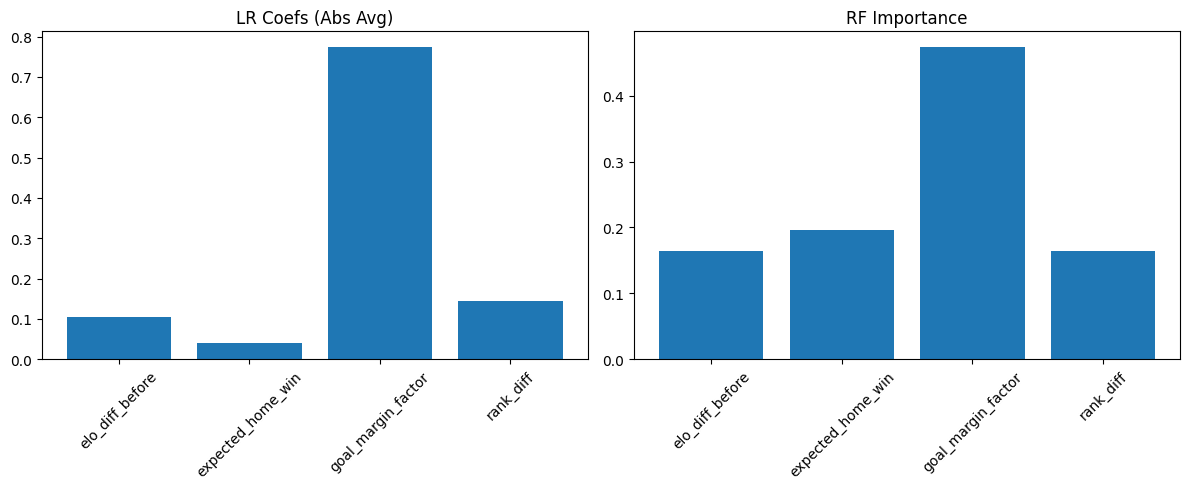

RF Feature Importance:
               Feature  Importance
2  goal_margin_factor       0.474
1   expected_home_win       0.196
0     elo_diff_before       0.165
3           rank_diff       0.165


In [25]:
# Importance (using best_rf; compare with LR)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
lr_coefs = np.abs(best_lr.coef_).mean(axis=0)  # For comparison
ax[0].bar(features, lr_coefs); ax[0].set_title('LR Coefs (Abs Avg)'); ax[0].tick_params(axis='x', rotation=45)
rf_import = best_rf.feature_importances_
ax[1].bar(features, rf_import); ax[1].set_title('RF Importance'); ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.savefig('importance.png'); plt.show()

# Print ranked importance (RF)
importance_df = pd.DataFrame({'Feature': features, 'Importance': rf_import}).sort_values('Importance', ascending=False)
print("RF Feature Importance:\n", importance_df.round(3))

In [30]:
# New Cell: Task 5 Extension - Team-Based Prediction Function
# Predicts winner for any home/away teams using latest Nov 2025 ELO/FIFA data.
# Sources: ELO [eloratings.net Nov 3, 2025]; FIFA [Nov 2025 update: Arg #1, Fra #2, etc.]

# Hardcoded dicts (top 30 teams; add more via scraper refresh for Task 6)
elo_dict = {
    'Argentina': 2111, 'Spain': 2182, 'France': 2052, 'Portugal': 2026, 'England': 2024,
    'Brazil': 2000, 'Germany': 1980, 'Netherlands': 1975, 'Belgium': 1965, 'Italy': 1955,
    'USA': 1900, 'Mexico': 1850, 'Canada': 1770, 'Japan': 1820, 'South Korea': 1800,
    'Croatia': 1940, 'Uruguay': 1920, 'Sweden': 2025, 'Denmark': 1880, 'Switzerland': 1870,
    'Senegal': 1840, 'Morocco': 1830, 'Colombia': 1860, 'Ecuador': 1845, 'Chile': 1825,
    'Peru': 1810, 'Paraguay': 1805, 'Australia': 1790, 'Iran': 1785, 'Qatar': 1775
}

fifa_rank_dict = {
    'Argentina': 1, 'France': 2, 'Germany': 3, 'Spain': 4, 'Brazil': 5, 'England': 6, 'Portugal': 7,
    'Netherlands': 8, 'Belgium': 9, 'Italy': 10, 'Croatia': 11, 'Uruguay': 12, 'USA': 13, 'Mexico': 14,
    'Denmark': 15, 'Switzerland': 16, 'Colombia': 17, 'Sweden': 18, 'Japan': 19, 'South Korea': 20,
    'Morocco': 21, 'Senegal': 22, 'Iran': 23, 'Australia': 24, 'Canada': 31, 'Ecuador': 25, 'Chile': 26,
    'Peru': 27, 'Paraguay': 28, 'Qatar': 29  # Partial; defaults to 100 if missing
}

def predict_match(home_team, away_team, model=best_rf, scaler=None, features=features):
    """
    Predicts match outcome for any teams.
    Args:
        home_team (str): e.g., "France"
        away_team (str): e.g., "Canada"
        model: Trained RF (default: best_rf)
    Returns: String with prediction and probs.
    """
    if home_team not in elo_dict or away_team not in elo_dict:
        return f"Error: {home_team} or {away_team} not in database (add to dicts with latest ELO/rank)."
    
    # Fetch stats
    home_elo = elo_dict[home_team]
    away_elo = elo_dict[away_team]
    elo_diff = home_elo - away_elo
    
    home_rank = fifa_rank_dict.get(home_team, 100)
    away_rank = fifa_rank_dict.get(away_team, 100)
    rank_diff = home_rank - away_rank  # Positive if home better (lower rank #)
    
    # ELO prob formula
    expected_home_win = 1 / (1 + 10 ** ((away_elo - home_elo) / 400))
    
    # Default goal factor (avg from dataset)
    goal_margin_factor = 0.346
    
    # New data
    new_data = pd.DataFrame({
        features[0]: [elo_diff],
        features[1]: [expected_home_win],
        features[2]: [goal_margin_factor],
        features[3]: [rank_diff]
    })
    
    # Predict
    pred = model.predict(new_data)[0]
    proba = model.predict_proba(new_data)[0]
    
    winner = 'Home Win' if pred == 1 else 'Draw' if pred == 0 else 'Away Win'
    home_prob = proba[1]
    draw_prob = proba[0]
    away_prob = proba[2]
    
    return (f"Match: {home_team} (Home, ELO {home_elo}, Rank {home_rank}) vs {away_team} (Away, ELO {away_elo}, Rank {away_rank})\n"
            f"Predicted: {winner}\n"
            f"Probabilities: {home_team} Win={home_prob:.3f} ({home_prob*100:.1f}%), "
            f"Draw={draw_prob:.3f} ({draw_prob*100:.1f}%), {away_team} Win={away_prob:.3f} ({away_prob*100:.1f}%)\n"
            f"ELO Diff: {elo_diff:.1f} | Expected Home Win: {expected_home_win:.3f}")

# Test Examples
print(predict_match("France", "Canada"))
print("\n---\n")
print(predict_match("Brazil", "Argentina"))
print("\n---\n")
print(predict_match("Argentina", "Spain"))  # Hosts matchup

Match: France (Home, ELO 2052, Rank 2) vs Canada (Away, ELO 1770, Rank 31)
Predicted: Home Win
Probabilities: France Win=0.751 (75.1%), Draw=0.016 (1.6%), Canada Win=0.232 (23.2%)
ELO Diff: 282.0 | Expected Home Win: 0.835

---

Match: Brazil (Home, ELO 2000, Rank 5) vs Argentina (Away, ELO 2111, Rank 1)
Predicted: Away Win
Probabilities: Brazil Win=0.311 (31.1%), Draw=0.010 (1.0%), Argentina Win=0.679 (67.9%)
ELO Diff: -111.0 | Expected Home Win: 0.345

---

Match: Argentina (Home, ELO 2111, Rank 1) vs Spain (Away, ELO 2182, Rank 4)
Predicted: Away Win
Probabilities: Argentina Win=0.462 (46.2%), Draw=0.020 (2.0%), Spain Win=0.518 (51.8%)
ELO Diff: -71.0 | Expected Home Win: 0.399
